# Image data and convolutional neural networks

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snss
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [4]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU NVIDIA A40


| Original | Translated | Coarsened | Super-resolved | 
| - | - | - | - | 
| ![original](images/image_pixels.png) | ![translated](images/image_shifted.png) | ![coarse](images/image_coarse.png)| ![fine](images/image_fine.png) |

Compared to structured tabular datasets like `Iris`, images pose some particular challenges. For example, the four images above all contain the same object. But they would be viewed very differently by an MLP.

| Version  | Vector | 
| - | - |
| Original |  <img src="images/flattened_pixels.png" width="1000" height="50"/> |
| Shifted |  <img src="images/shifted_pixels.png" width="1000" height="50"/> |
| Coarsened |  <img src="images/coarsened_pixels.png" width="500" height="50"/> |
| Super-resolved |  <img src="images/fine_pixels.png" width="2000" height="50"/> |

If we trained a MLP only on centered MNIST images, the shifted image might cause a completely different set of activations in the hidden layer, leading to misclassification. And the coarsened/super-resolved images would have sizes that are incompatible with the hidden layer weight matrix.

Animal vision tends to overcome these problems, and CNNs are loosely inspired by experimental results on the visual cortex. These experiments revealed a hierarchical structure with **simple** and **complex** cells. The simple cells identify features such as edges within narrow visual regions, or **receptive fields**. The complex cells probe a larger region and their activation is less sensitive on the exact position of an object within their view.

Visual perception, therefore, roughly follows this process
\begin{align}
    \text{Retinal stimulation} \underbrace{\rightarrow}_{\text{Simple cells}} \text{Low-level features} \underbrace{\rightarrow}_{\text{Complex cells}} \text{High-level features} \underbrace{\rightarrow}_{\dots} \text{Recognition} 
\end{align}

Convolutional neural networks (CNN) aim to learn **feature maps** that incorporate several key aspects:
- **Sparse connectivity** - like simple cells, each output of a CNN layer accesses only a small region of the input
<img src="images/sparse_connectivity.png" width="500"/>
- **Weight sharing** - like complex cells, CNNs produce outputs that are insensitive to position by applying the same weights at different places, and *pooling* the outputs

<img src="images/weight_sharing.png" width="500"/>

Combined, these properties give CNNs an important property called **translation equivariance**
\begin{align}
    f\big(g(x)\big) = g\big(f(x)\big) & & \mbox{f is equivariant to g} \\
\end{align}
Suppose we have a translation operator $T$ that acts on an image by shifting every pixel to the right by one: $T(I_{x,y}) = I_{x-1, y}$. 
A CNN layer produces a feature map $f_{x,y}(I)$ that is equivariant to $T$
\begin{align}
    f_{x,y}\big( T (I_{x,y})\big) = f_{x,y}( I_{x-1,y} ) = f_{x-1,y} (I_{x,y}) = T\big( f_{x,y} ( I_{x,y}) \big)
\end{align}
The feature map of a shifted image is identical to the shifted feature map of the original image. 

How do we possibly make this work in practice? That's the focus of the lecture today. 

## What is a convolution?

The **convolution** of two functions $f(x), w(x)$ is
\begin{align}
    (f * w)(x) = \int_{-\infty}^{\infty} f(t) \, w(x-t) \, dt
\end{align}
or equivalently
\begin{align}
    (f * w)(x) = \int_{-\infty}^{\infty} f(x - t) \, w(x) \, dt
\end{align}

Loosely, it's a way of "mixing up" two functions. We sometimes refer to $w$ as a *weighting* function, or alternatively a *kernel* function. 

Convolution has several very nice algebraic properties which we don't need to get into. Read more [here](https://en.wikipedia.org/wiki/Convolution).

Computers are finite objects. So in general, we cannot evaluate integrals with infinitesimally small differentials $dt$. Instead, we compute the **discrete convolution** using a sum
\begin{align}
    z[i] = \sum_{j=-\infty}^{\infty} x[i-j] \, w[j]
\end{align}
Note that we also cannot evaluate sums over infinite domains. So we often work with finite **kernels** such that
\begin{align}
    z[i] = \sum_{j=-K}^{K} x[i-j] \, w[j]
\end{align}

<img src="images/discrete_convolution.png" width="500"/>

### Implementing discrete convolutions

In [26]:
from math import floor

def discrete_convolution_1d(x, w, pad=0, stride=1):
    """ x is a numpy array of shape [N,]
        w is a numpy array of shape [k,]
    """
    N = x.shape[0]
    k = w.shape[0]
    out_size = floor((N + 2*pad - k) / stride + 1)

    if pad > 0:
        zeros = np.zeros(pad)
        x_pad = np.concatenate([zeros, x, zeros])
    else:
        x_pad = x

    result = []
    for ii in range(0, x_pad.shape[0] - k + 1, stride):
        result.append(
            np.sum(x_pad[ii:ii+k] * w[::-1])
        )
    return np.array(result)

x = np.array([1, 2, 3, 2, 2, 5, 2, 1], dtype=float)
w = np.array([-1, 0, 1]) # 1-D edge filter (first-order)

print(discrete_convolution_1d(x, w, pad=1, stride=1))
print(np.convolve(x, w, mode='same'))

[-2. -2.  0.  1. -3.  0.  4.  2.]
[-2. -2.  0.  1. -3.  0.  4.  2.]


In [67]:
def discrete_convolution_2d(x, w, pad=0, stride=1):
    N1, N2 = x.shape
    k1, k2 = w.shape

    if pad > 0:
        x_pad = np.zeros([N1+2*pad, N2+2*pad])
        x_pad[pad:-pad, pad:-pad] = x
    else:
        x_pad = x

    o1 = floor((N1 + 2*pad - k1) / stride + 1)
    o2 = floor((N2 + 2*pad - k2) / stride + 1)

    result = np.zeros([o1, o2])
    for i1, j1 in enumerate(range(0, x_pad.shape[0] - k1 + 1, stride)):
        for i2, j2 in enumerate(range(0, x_pad.shape[1] - k2 + 1, stride)):
            result[i1, i2] = np.sum(
                x_pad[j1:j1+k1, j2:j2+k2] * w[::-1, ::-1]
            )
    return result

x = np.random.randint(low=0, high=10, size=(5, 5)).astype(float)
print('For array x\n', x)
w = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)

print('Our implementation:\n', discrete_convolution_2d(x, w, pad=1))
from scipy.signal import convolve2d
print('Scipy implementation:\n', convolve2d(x, w, mode='same'))

For array x
 [[4. 0. 2. 3. 8.]
 [3. 5. 2. 7. 5.]
 [1. 9. 8. 4. 5.]
 [5. 2. 8. 7. 1.]
 [8. 1. 4. 7. 5.]]
Our implementation:
 [[ -5.   5.  -8. -15.  13.]
 [-19.  -3.  -2.  -9.  21.]
 [-25. -16.   3.  10.  22.]
 [-14.  -9. -11.  16.  25.]
 [ -4.   5. -17.   5.  21.]]
Scipy implementation:
 [[ -5.   5.  -8. -15.  13.]
 [-19.  -3.  -2.  -9.  21.]
 [-25. -16.   3.  10.  22.]
 [-14.  -9. -11.  16.  25.]
 [ -4.   5. -17.   5.  21.]]


### Speeding up discrete convolutions

In [68]:
# For loops are slow, how can we speed this up?
print(f"x is a float array of size {x.shape}")
print(f"A stride along dim 0 is {x.strides[0]} bytes: x[0] = {x[0]}")
print(f"A stride along dim 1 is {x.strides[1]} bytes: x[0,0] = {x[0, 0]}")


x is a float array of size (5, 5)
A stride along dim 0 is 40 bytes: x[0] = [4. 0. 2. 3. 8.]
A stride along dim 1 is 8 bytes: x[0,0] = 4.0


In [69]:
from numpy.lib.stride_tricks import as_strided
def fancy_convolution_2d(x, w, pad=0, stride=1, verbose=True):
    if verbose:
        print("Input x = \n", x)
    N1, N2 = x.shape
    k1, k2 = w.shape

    if pad > 0:
        x_pad = np.zeros([N1+2*pad, N2+2*pad])
        x_pad[pad:-pad, pad:-pad] = x
    else:
        x_pad = x

    o1 = floor((N1 + 2*pad - k1) / stride + 1)
    o2 = floor((N2 + 2*pad - k2) / stride + 1)
    
    # Instead of running nested for loops, add strides to the array to get windows equal to our kernel size
    x_stride = as_strided(
        x_pad,
        shape=(o1, # For each element in my output array along dim 0
               o2, # For each element in my output array along dim 1
               k1, # Give me a window of size k1, k2
               k2),
        strides=(x_pad.strides[0],
                 x_pad.strides[1],
                 x_pad.strides[0], 
                 x_pad.strides[1])
    )
    
    if verbose:
        print(f"X has shape {x_stride.shape} and strides {x_stride.strides}")
        print(f"X[0, 0] = \n{x_stride[0, 0]}")
        print(f"X[1, 1] = \n{x_stride[1, 1]}")
        print()

    return np.einsum(
        'ijkl,kl->ij', x_stride, w[::-1, ::-1]
    )

print('Our implementation:\n', fancy_convolution_2d(x, w, pad=1))
print('Scipy implementation:\n', convolve2d(x, w, mode='same'))

Input x = 
 [[4. 0. 2. 3. 8.]
 [3. 5. 2. 7. 5.]
 [1. 9. 8. 4. 5.]
 [5. 2. 8. 7. 1.]
 [8. 1. 4. 7. 5.]]
X has shape (5, 5, 3, 3) and strides (56, 8, 56, 8)
X[0, 0] = 
[[0. 0. 0.]
 [0. 4. 0.]
 [0. 3. 5.]]
X[1, 1] = 
[[4. 0. 2.]
 [3. 5. 2.]
 [1. 9. 8.]]

Our implementation:
 [[ -5.   5.  -8. -15.  13.]
 [-19.  -3.  -2.  -9.  21.]
 [-25. -16.   3.  10.  22.]
 [-14.  -9. -11.  16.  25.]
 [ -4.   5. -17.   5.  21.]]
Scipy implementation:
 [[ -5.   5.  -8. -15.  13.]
 [-19.  -3.  -2.  -9.  21.]
 [-25. -16.   3.  10.  22.]
 [-14.  -9. -11.  16.  25.]
 [ -4.   5. -17.   5.  21.]]


In [70]:
from time import time

x = np.random.randint(low=0, high=10, size=(100, 100)).astype(float)

t = time()
basic = discrete_convolution_2d(x, w, pad=1)
print(f"Basic convolution took {time()-t:.06f} s")

t = time()
fancy = fancy_convolution_2d(x, w, pad=1, verbose=False)
print(f"Fancy convolution took {time()-t:.06f} s")

t = time()
theirs = convolve2d(x, w, mode='same')
print(f"Scipy convolution took {time()-t:.06f} s")

Basic convolution took 0.038502 s
Fancy convolution took 0.000399 s
Scipy convolution took 0.000311 s


### Example: Gradient filter

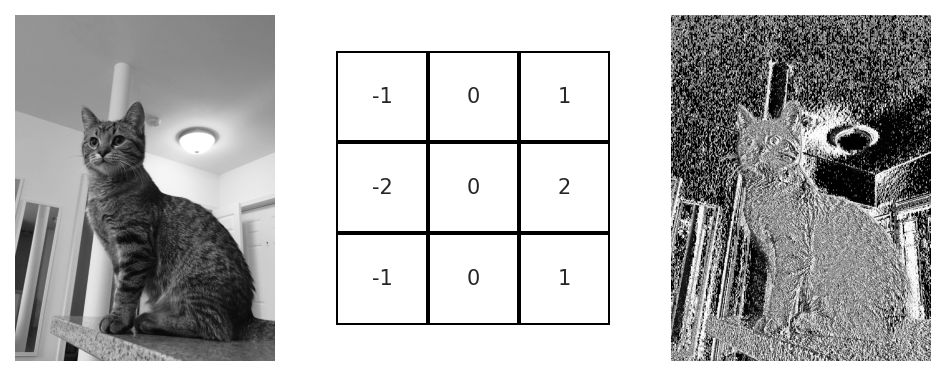

In [71]:
from PIL import Image
import seaborn as sns
from matplotlib.colors import ListedColormap
img = np.array(Image.open('images/emmy.jpg').convert('L'))

from scipy.ndimage import convolve
filtered = convolve(img, w)

fig, ax = plt.subplots(1, 3, figsize=(8, 3))
ax[0].imshow(img, cmap='Greys_r')
sns.heatmap(data=w, annot=True, ax=ax[1], linecolor='black', linewidths=1, cmap=ListedColormap(['white']), cbar=False)
ax[1].set_aspect('equal')

ax[2].imshow(filtered, cmap='Greys_r')

for a in ax:
    a.axis('off')

### Example: edge detection (Sobel)

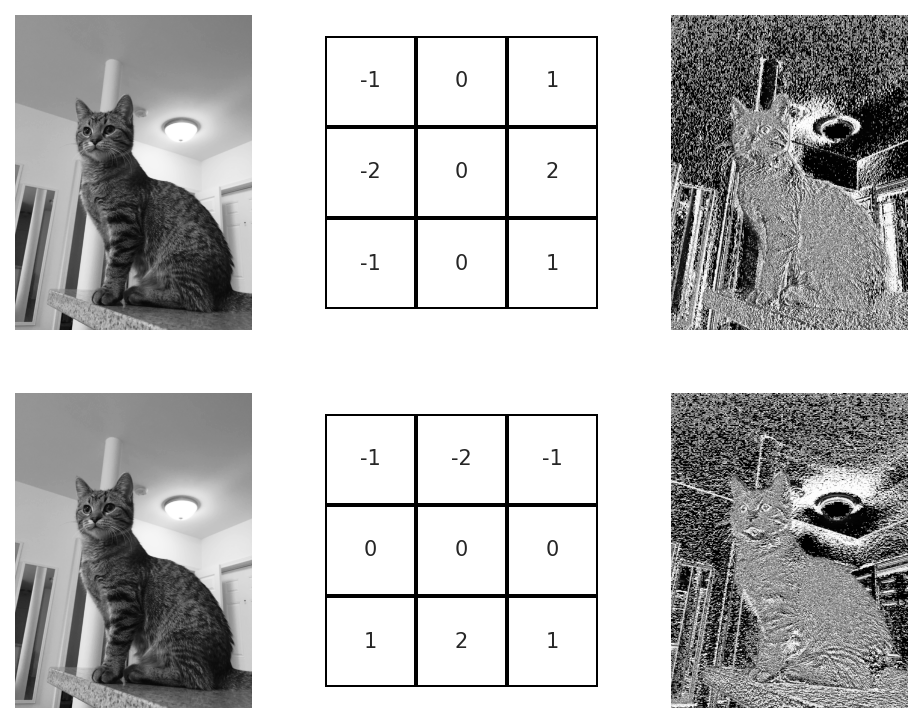

In [72]:
from PIL import Image
import seaborn as sns
from matplotlib.colors import ListedColormap
img = np.array(Image.open('images/emmy.jpg').convert('L'))

from scipy.ndimage import convolve
filtered_x = convolve(img, w)
filtered_y = convolve(img, w.T)

fig, ax = plt.subplots(2, 3, figsize=(8, 6))
ax[0,0].imshow(img, cmap='Greys_r')
ax[1,0].imshow(img, cmap='Greys_r')
sns.heatmap(data=w, annot=True, ax=ax[0,1], linecolor='black', linewidths=1, cmap=ListedColormap(['white']), cbar=False)
ax[0,1].set_aspect('equal')
sns.heatmap(data=w.T, annot=True, ax=ax[1,1], linecolor='black', linewidths=1, cmap=ListedColormap(['white']), cbar=False)
ax[1,1].set_aspect('equal')
ax[0,2].imshow(filtered_x, cmap='Greys_r')
ax[1,2].imshow(filtered_y, cmap='Greys_r')

for a in ax.flatten():
    a.axis('off')

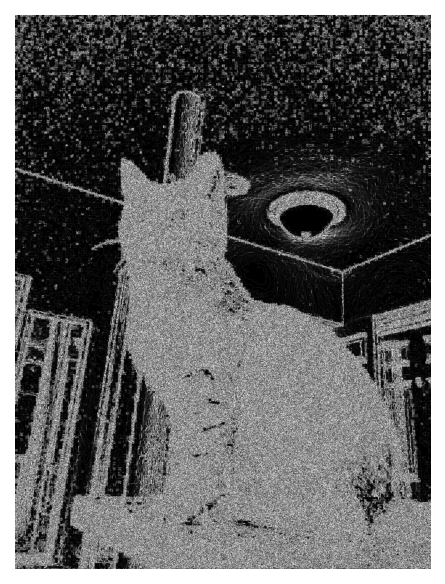

In [73]:
ax = plt.figure().gca()
ax.imshow(filtered_x**2 + filtered_y**2, cmap='Greys_r')
ax.axis('off');

## Convolutions and Cross-Correlations as a sliding dot product

Sketch this on the whiteboard

## Image data often has multiple channels

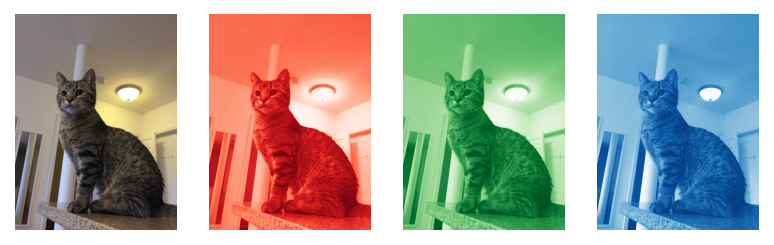

In [92]:
from PIL import Image
import seaborn as sns
from matplotlib.colors import ListedColormap
img = np.array(Image.open('images/emmy.jpg').convert('RGB'))

fig, ax = plt.subplots(1, 4)
ax[0].imshow(img)
ax[1].imshow(img[..., 0], cmap='Reds_r')
ax[2].imshow(img[..., 1], cmap='Greens_r')
ax[3].imshow(img[..., 2], cmap='Blues_r')

for a in ax:
    a.axis('off')

(1674, 1256, 6)


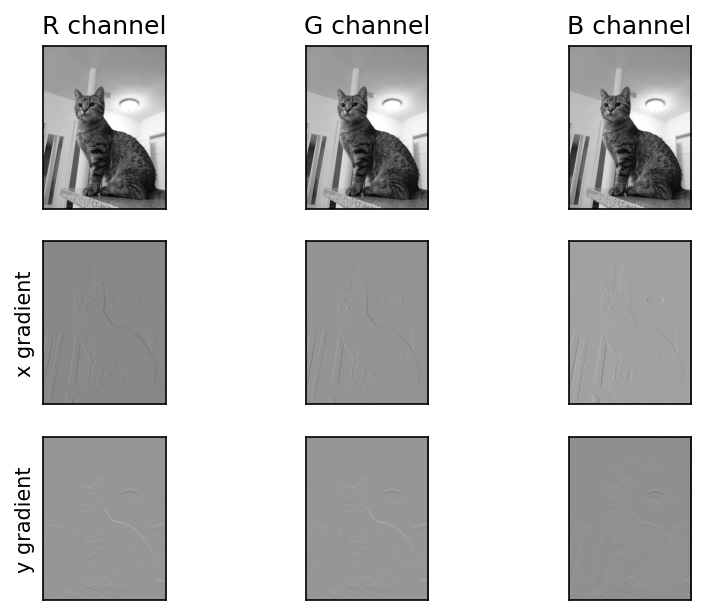

In [111]:
# Convolution that mixes channels
from numpy.lib.stride_tricks import as_strided
def multichannel_convolution_2d(x, w, pad=0, stride=1, verbose=True):
    N1, N2, c = x.shape
    k1, k2, c_in, c_out = w.shape

    if pad > 0:
        x_pad = np.zeros([N1+2*pad, N2+2*pad, c])
        x_pad[pad:-pad, pad:-pad] = x
    else:
        x_pad = x

    o1 = floor((N1 + 2*pad - k1) / stride + 1)
    o2 = floor((N2 + 2*pad - k2) / stride + 1)
    
    # Instead of running nested for loops, add strides to the array to get windows equal to our kernel size
    x_stride = as_strided(
        x_pad,
        shape=(o1, # For each element in my output array along dim 0
               o2, # For each element in my output array along dim 1
               c, # For each feature at that pixel position
               k1, # Give me a window of size k1, k2
               k2),
        strides=(x_pad.strides[0],
                 x_pad.strides[1],
                 x_pad.strides[2],
                 x_pad.strides[0], 
                 x_pad.strides[1])
    )
    
    return np.einsum(
        'ijckl,klcd->ijd', x_stride, w[::-1, ::-1]
    )

w_array = np.zeros([*w.shape, 3, 6])
w_array[:, :, 0, 0] = w
w_array[:, :, 0, 1] = w.T
w_array[:, :, 1, 2] = w
w_array[:, :, 1, 3] = w.T
w_array[:, :, 2, 4] = w
w_array[:, :, 2, 5] = w.T

out = multichannel_convolution_2d(img, w_array, stride=1, pad=1)
print(out.shape)

fig, ax = plt.subplots(3, 3)
for ii in range(3):
    ax[0, ii].imshow(img[..., 0], cmap='Greys_r')
    ax[1, ii].imshow(out[..., ii*2], cmap='Greys_r')
    ax[2, ii].imshow(out[..., ii*2 + 1], cmap='Greys_r')


ax[0,0].set_title('R channel')
ax[0,1].set_title('G channel')
ax[0,2].set_title('B channel')

ax[1,0].set_ylabel('x gradient')
ax[2,0].set_ylabel('y gradient')

for a in ax.flatten():
    a.set(xticks=[], yticks=[])
    a.grid(False)

(-0.5, 1255.5, 1673.5, -0.5)

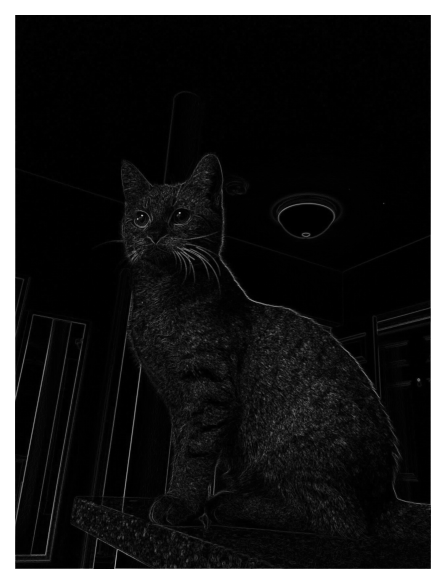

In [118]:
ax = plt.figure().gca()
edge = np.linalg.norm(out, axis=2)
ax.imshow(edge, cmap='Greys_r')
ax.axis('off')

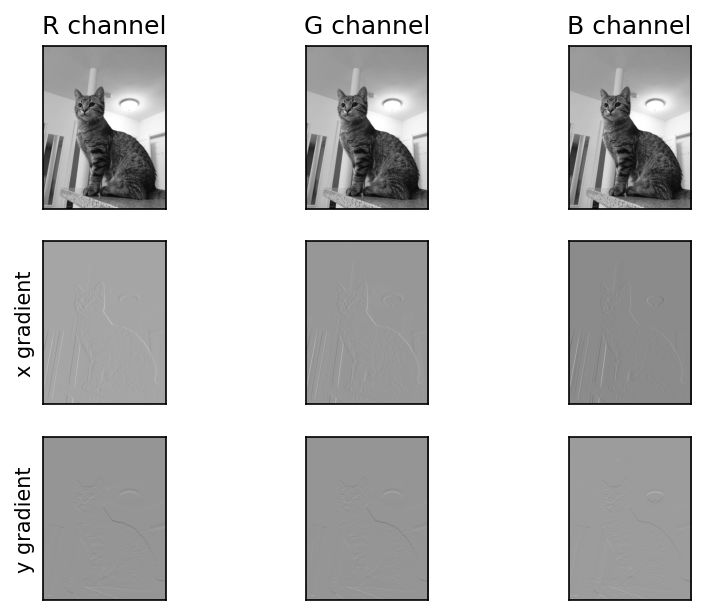

In [107]:
from torch.nn.functional import conv2d
out = conv2d(input=torch.FloatTensor(img).permute(2, 0, 1)[None],
             weight=torch.FloatTensor(w_array).permute(3, 2, 0, 1),
             stride=1, padding='same')

fig, ax = plt.subplots(3, 3)
for ii in range(3):
    ax[0, ii].imshow(img[..., 0], cmap='Greys_r')
    ax[1, ii].imshow(out[0, ii*2], cmap='Greys_r')
    ax[2, ii].imshow(out[0, ii*2 + 1], cmap='Greys_r')


ax[0,0].set_title('R channel')
ax[0,1].set_title('G channel')
ax[0,2].set_title('B channel')

ax[1,0].set_ylabel('x gradient')
ax[2,0].set_ylabel('y gradient')

for a in ax.flatten():
    a.set(xticks=[], yticks=[])
    a.grid(False)

## Building a CNN

Now that we understand convolution, and why we should care about it, we are almost ready to implement a CNN. In general, a CNN architecture contains:
- **Convolution layers** which execute a discrete convolution with a learnable weighting or kernel function
- **Pooling layers** which perform spatial downsampling (mimicking the role of complex cells in a visual cortex)
- **Fully-connected layers** which make determinations based on the high-level features at the end of the network

For this example, we'll use MNIST. But since we're using `torch` now, we can use the MNIST located in torchvision

In [119]:
import torch
import torchvision
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
mnist = torchvision.datasets.MNIST(root='~/scr10/', train=True, transform=transform, download=True)

from torch.utils.data import random_split
mnist_train, mnist_val, mnist_test = random_split(mnist, [0.6, 0.2, 0.2])
print('Training dataset has length', len(mnist_train))
print('Training dataset has length', len(mnist_val))
print('Training dataset has length', len(mnist_test))

Training dataset has length 36000
Training dataset has length 12000
Training dataset has length 12000


In [120]:
x, y = mnist_train[0]
print('Input has shape', x.shape, 'and the output is', y)

Input has shape torch.Size([1, 28, 28]) and the output is 6


In [121]:
from torch.utils.data import DataLoader
batch_size = 64
torch.manual_seed(42)
train_loader = DataLoader(mnist_train, batch_size, shuffle=True)
val_loader = DataLoader(mnist_val, batch_size, shuffle=False)

### CNN definition

In [122]:
import torch.nn as nn
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)

z = model(x[None])
print(f'Model transforms input from size {x[None].shape} into {z.shape}')
model

Model transforms input from size torch.Size([1, 1, 28, 28]) into torch.Size([1, 32, 7, 7])


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [123]:
model.add_module('flatten', nn.Flatten())

z = model(x[None])
print(f'Model transforms input from size {x[None].shape} into {z.shape}')
model

Model transforms input from size torch.Size([1, 1, 28, 28]) into torch.Size([1, 1568])


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
)

In [124]:
model.add_module('dropout', nn.Dropout(p=0.5)) # Improves generalization
model.add_module('fc1', nn.Linear(1568, 256))
model.add_module('relu', nn.ReLU())
model.add_module('fc2', nn.Linear(256, 10))

z = model(x[None])
print(f'Model transforms input from size {x[None].shape} into {z.shape}')
model

Model transforms input from size torch.Size([1, 1, 28, 28]) into torch.Size([1, 10])


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1568, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

### Model training

In [125]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')

print('Working on device', device)
model = model.to(device)

Working on device cuda:0


In [126]:
from tqdm.auto import tqdm
def train(model, optimizer, loss_func, train_loader, val_loader, num_epochs=10):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss_ = 0.
        train_correct_ = 0.
        for xb, yb in tqdm(train_loader, leave=False):
            optimizer.zero_grad()
            
            xb = xb.to(device)
            yb = yb.to(device)
            y_pred = model(xb)
            
            loss = loss_func(y_pred, yb)
            loss.backward()
            optimizer.step()
            
            train_loss_ += loss.item() * yb.shape[0]
            train_correct_ += (torch.argmax(y_pred, dim=1) == yb).float().sum().item()
            
        train_loss.append(train_loss_ / len(train_loader.dataset))
        train_acc.append(train_correct_ / len(train_loader.dataset))

        model.eval()
        with torch.no_grad():
            val_loss_ = 0.
            val_correct_ = 0.
            for xb, yb in tqdm(val_loader, leave=False):
                
                xb = xb.to(device)
                yb = yb.to(device)
                y_pred = model(xb)
                
                loss = loss_func(y_pred, yb)
                val_loss_ += loss.item() * yb.shape[0]
                val_correct_ += (torch.argmax(y_pred, dim=1) == yb).float().sum().item()
            val_loss.append(val_loss_ / len(val_loader.dataset))
            val_acc.append(val_correct_ / len(val_loader.dataset))

        print(f'Epoch {epoch+1} | '
              f'Train loss { train_loss[-1]:.3f} | '
              f'Train acc { train_acc[-1]:.3f} | '
              f'Val loss { val_loss[-1]:.3f} | '
              f'Val acc { val_acc[-1]:.3f}'
        )

    return train_loss, train_acc, val_loss, val_acc

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loss, train_acc, val_loss, val_acc = train(model, optimizer, loss, train_loader, val_loader, num_epochs=10)

  0%|          | 0/563 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 | Train loss 0.339 | Train acc 0.896 | Val loss 0.100 | Val acc 0.971


  0%|          | 0/563 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

...

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 9 | Train loss 0.039 | Train acc 0.986 | Val loss 0.034 | Val acc 0.991


  0%|          | 0/563 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 10 | Train loss 0.035 | Train acc 0.988 | Val loss 0.040 | Val acc 0.989


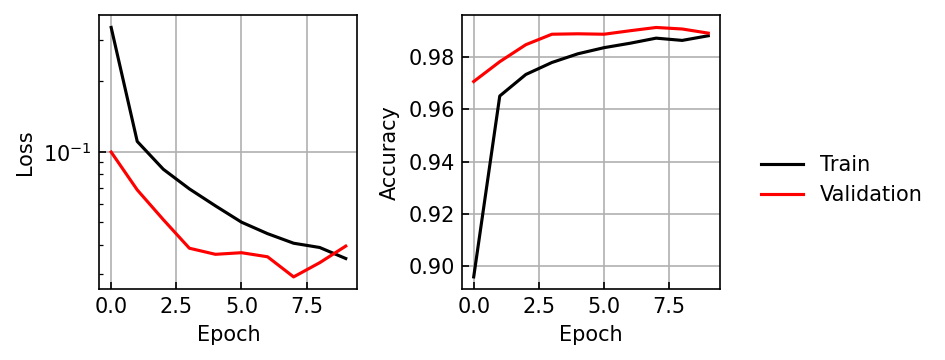

In [127]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(train_loss, color='black', label='Train')
ax[0].plot(val_loss, color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='Loss', yscale='log')

ax[1].plot(train_acc, color='black', label='Train')
ax[1].plot(val_acc, color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Accuracy')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

In [128]:
# Inference
model.eval()
test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)
with torch.no_grad():
    test_correct_ = 0.
    for xb, yb in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        yb = yb.to(device)
        y_pred = model(xb)
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct_ += (y_pred == yb).float().sum().item()
    test_acc = test_correct_ / len(test_loader.dataset)

print(f"Test accuracy: {test_acc:.3f}")

  0%|          | 0/94 [00:00<?, ?it/s]

Test accuracy: 0.988


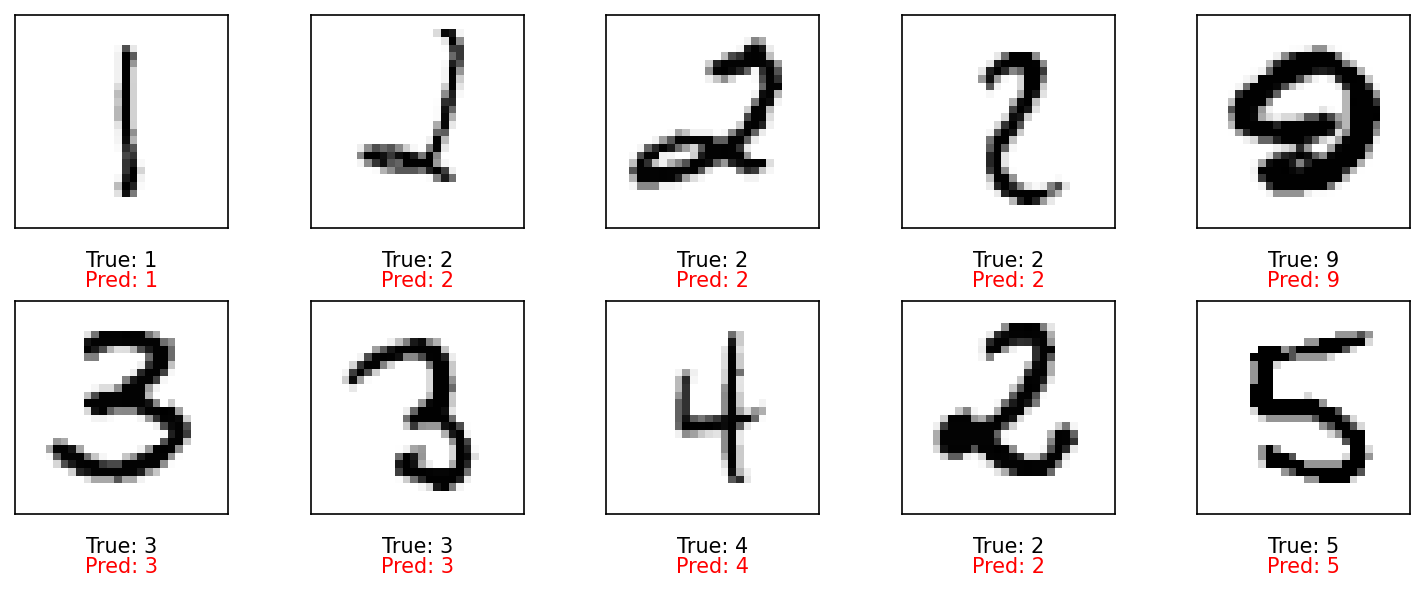

In [133]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4), sharex=True, sharey=True)
ax = ax.flatten()
for ii in range(10):
    ax[ii].imshow(xb[ii].squeeze().cpu().numpy(), cmap='Greys')
    ax[ii].text(0.5, -0.2, f'True: {yb[ii]}', va='bottom', ha='center', transform=ax[ii].transAxes)
    ax[ii].text(0.5, -0.2, f'Pred: {y_pred[ii]}', color='red', va='top', ha='center', transform=ax[ii].transAxes)
    ax[ii].set(xticks=[], yticks=[])
plt.tight_layout()

## Spend some time playing around with visualizations

[Check out this fun online tool for NN weight visualization](https://adamharley.com/nn_vis/)